# Modelo: K-Means Clustering
**Dataset:** Side-scan sonar imaging for Mine detection
**Algoritmo:** KMeans (scikit-learn)  
**Parâmetros:** n_clusters=2 | init=k-means++ | n_init=10 | max_iter=300  
**Normalização:** StandardScaler  

**Nota:** K-Means é um algoritmo de aprendizado **não supervisionado**. Os rótulos reais (y) são utilizados apenas para avaliação posterior dos clusters, não durante o treinamento.

## 1. Importações e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    adjusted_rand_score, silhouette_score,
    precision_score, recall_score, f1_score
)
# Bibliotecas de monitoramento de performance computacional
import time
import tracemalloc
import platform
import psutil
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Carregamento dos Dados

In [2]:
PATH = r"../sonar_data_matriz.csv"

dataset = pd.read_csv(PATH, header=None)
print("Shape:", dataset.shape)
print("\nDistribuição de classes (original):")
print(dataset.iloc[:, -1].value_counts())
dataset.head()

Shape: (208, 61)

Distribuição de classes (original):
60
M    111
R     97
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 3. Pré-processamento e Normalização

In [3]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Codificação: M=1 (Mina), R=0 (Rocha) — usado apenas para avaliação
y_true = np.where(y == 'M', 1, 0)

# K-Means é sensível à escala — normalização obrigatória
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Total de amostras : {X_scaled.shape[0]}")
print(f"Total de features : {X_scaled.shape[1]}")
print(f"Classes reais     : 0=Rocha ({(y_true==0).sum()}), 1=Mina ({(y_true==1).sum()})")
print("Normalização: StandardScaler aplicado")

Total de amostras : 208
Total de features : 60
Classes reais     : 0=Rocha (97), 1=Mina (111)
Normalização: StandardScaler aplicado


## 4. Escolha Ótima de K (Método do Cotovelo + Silhouette)

Como o K-Means não supervisionado não conhece os rótulos, usamos o método do cotovelo (inércia) e o Silhouette Score para determinar o número ideal de clusters.

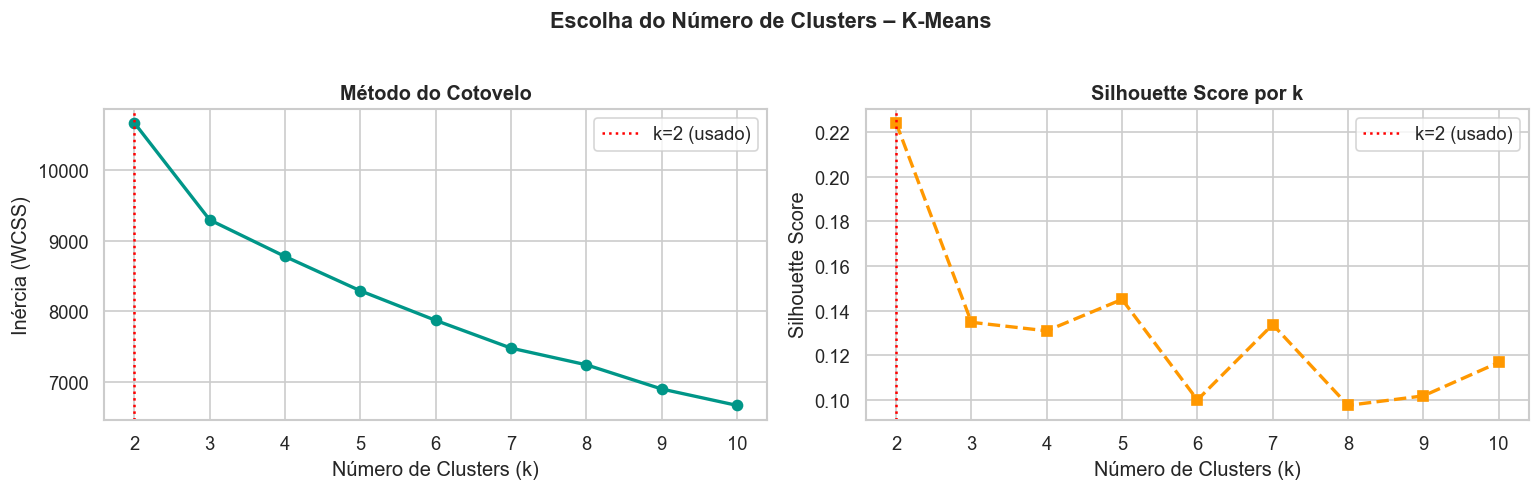

Silhouette scores: ['0.2242', '0.1347', '0.1309', '0.1450', '0.0999', '0.1337', '0.0974', '0.1017', '0.1167']


In [4]:
k_range   = range(2, 11)
inertias  = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cotovelo
axes[0].plot(list(k_range), inertias, 'o-', color='#009688', lw=2)
axes[0].axvline(2, color='red', ls=':', lw=1.5, label='k=2 (usado)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_title('Método do Cotovelo', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(list(k_range))

# Silhouette
axes[1].plot(list(k_range), silhouettes, 's--', color='#FF9800', lw=2)
axes[1].axvline(2, color='red', ls=':', lw=1.5, label='k=2 (usado)')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(k_range))

plt.suptitle('Escolha do Número de Clusters – K-Means', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/kmeans/kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f"Silhouette scores: {[f'{s:.4f}' for s in silhouettes]}")

## 5. Treinamento do Modelo (k=2)

In [5]:
modelo = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

clusters = modelo.fit_predict(X_scaled)

print(f"Modelo K-Means (k=2) treinado com sucesso")
print(f"Iterações até convergência : {modelo.n_iter_}")
print(f"Inércia final              : {modelo.inertia_:.4f}")
print(f"\nDistribuição dos clusters:")
unique, counts = np.unique(clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} amostras")

Modelo K-Means (k=2) treinado com sucesso
Iterações até convergência : 12
Inércia final              : 10657.0735

Distribuição dos clusters:
  Cluster 0: 159 amostras
  Cluster 1: 49 amostras


## 6. Alinhamento dos Clusters com os Rótulos Reais

Como K-Means não garante que o cluster 0 corresponda à classe 0, verificamos o alinhamento e remapeamos se necessário.

In [6]:
from scipy.stats import mode

# Mapeia cada cluster ao rótulo real majoritário
y_pred = np.zeros_like(clusters)
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    majority = mode(y_true[mask], keepdims=True).mode[0]
    y_pred[mask] = majority

print("Mapeamento cluster → classe real:")
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    majority = mode(y_true[mask], keepdims=True).mode[0]
    classe = 'Mina' if majority == 1 else 'Rocha'
    print(f"  Cluster {cluster_id} → {classe} ({majority})")

Mapeamento cluster → classe real:
  Cluster 0 → Mina (1)
  Cluster 1 → Mina (1)


## 7. Métricas de Desempenho

In [7]:
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
ari       = adjusted_rand_score(y_true, clusters)
sil       = silhouette_score(X_scaled, clusters)

metricas = {
    "Acurácia (pós-alinhamento)" : acc,
    "Precisão (Mina)"            : precision,
    "Recall (Mina)"              : recall,
    "F1-Score (Mina)"            : f1,
    "Adjusted Rand Index (ARI)"  : ari,
    "Silhouette Score"           : sil,
}

df_metricas = pd.DataFrame(metricas.items(), columns=["Métrica", "Valor"])
df_metricas["Valor"] = df_metricas["Valor"].map(lambda v: f"{v:.4f}")
print("=== MÉTRICAS – K-MEANS ===")
display(df_metricas)

=== MÉTRICAS – K-MEANS ===


,Métrica,Valor
0,Acurácia (pós-alinhamento),0.5337
1,Precisão (Mina),0.5337
2,Recall (Mina),1.0000
3,F1-Score (Mina),0.6959
4,Adjusted Rand Index (ARI),-0.0044
5,Silhouette Score,0.2242


## 8. Performance Computacional

Métricas de uso de CPU, memória RAM e tempo de execução coletadas durante o treinamento e a inferência do modelo.

In [8]:
# Informações do ambiente
print("=== AMBIENTE DE EXECUÇÃO ===")
print(f"  SO          : {platform.system()} {platform.release()}")
print(f"  Processador : {platform.processor() or platform.machine()}")
print(f"  Núcleos CPU : {psutil.cpu_count(logical=False)} físicos / {psutil.cpu_count()} lógicos")
print(f"  RAM total   : {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"  Python      : {platform.python_version()}")

# CPU e RAM antes do treino
cpu_antes = psutil.cpu_percent(interval=0.5)
proc      = psutil.Process(os.getpid())
ram_antes = proc.memory_info().rss / 1e6  # MB

# Treino com medição de tempo e memória
tracemalloc.start()
t0_treino = time.perf_counter()

_modelo_perf = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
_modelo_perf.fit(X_scaled)

t1_treino = time.perf_counter()
mem_pico_treino, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_treino       = t1_treino - t0_treino
mem_pico_treino_mb = mem_pico_treino / 1e6

# Inferência (predict) com medição de tempo
t0_inf = time.perf_counter()
_ = _modelo_perf.predict(X_scaled)
t1_inf = time.perf_counter()
tempo_inferencia  = t1_inf - t0_inf
tempo_por_amostra = tempo_inferencia / len(X_scaled) * 1000  # ms

# CPU e RAM depois
cpu_depois = psutil.cpu_percent(interval=0.5)
ram_depois = proc.memory_info().rss / 1e6

# Tabela de resultados
df_perf = pd.DataFrame({
    "Métrica": [
        "Tempo de Treino (s)",
        "Tempo de Inferência (s)",
        "Tempo por Amostra (ms)",
        "Pico de Memória — Treino (MB)",
        "RAM do Processo — Antes (MB)",
        "RAM do Processo — Depois (MB)",
        "Delta RAM (MB)",
        "CPU antes do treino (%)",
        "CPU depois do treino (%)",
        "Total de Amostras",
        "Núcleos lógicos disponíveis",
    ],
    "Valor": [
        f"{tempo_treino:.6f}",
        f"{tempo_inferencia:.6f}",
        f"{tempo_por_amostra:.4f}",
        f"{mem_pico_treino_mb:.4f}",
        f"{ram_antes:.2f}",
        f"{ram_depois:.2f}",
        f"{ram_depois - ram_antes:.2f}",
        f"{cpu_antes:.1f}",
        f"{cpu_depois:.1f}",
        str(len(X_scaled)),
        str(psutil.cpu_count()),
    ]
})

print("\n=== PERFORMANCE COMPUTACIONAL — K-MEANS ===")
display(df_perf)

=== AMBIENTE DE EXECUÇÃO ===
  SO          : Windows 10
  Processador : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
  Núcleos CPU : 6 físicos / 12 lógicos
  RAM total   : 16.53 GB
  Python      : 3.11.9

=== PERFORMANCE COMPUTACIONAL — K-MEANS ===


,Métrica,Valor
0,Tempo de Treino (s),0.030663
1,Tempo de Inferência (s),0.000487
2,Tempo por Amostra (ms),0.0023
3,Pico de Memória — Treino (MB),0.0164
4,RAM do Processo — Antes (MB),218.37
5,RAM do Processo — Depois (MB),218.73
6,Delta RAM (MB),0.36
7,CPU antes do treino (%),29.6
8,CPU depois do treino (%),13.6
9,Total de Amostras,208


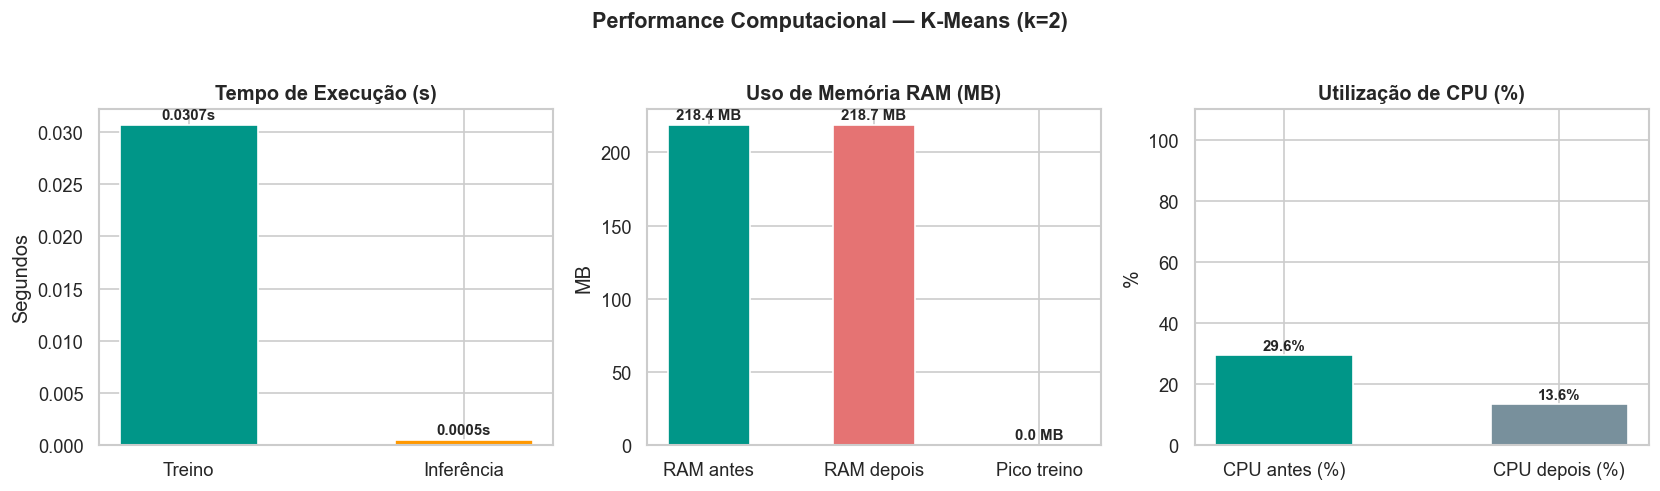

In [9]:
# ── Visualização das métricas de performance ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Tempo
labels_t = ["Treino", "Inferência"]
vals_t   = [tempo_treino, tempo_inferencia]
bars = axes[0].bar(labels_t, vals_t, color=["#009688", "#FF9800"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_t):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_t)*0.01,
                 f"{v:.4f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Tempo de Execução (s)", fontweight="bold")
axes[0].set_ylabel("Segundos")

# 2. Memória RAM
labels_m = ["RAM antes", "RAM depois", "Pico treino"]
vals_m   = [ram_antes, ram_depois, mem_pico_treino_mb]
bars = axes[1].bar(labels_m, vals_m, color=["#009688", "#E57373", "#FFB74D"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_m):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_m)*0.01,
                 f"{v:.1f} MB", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Uso de Memória RAM (MB)", fontweight="bold")
axes[1].set_ylabel("MB")

# 3. CPU
labels_c = ["CPU antes (%)", "CPU depois (%)"]
vals_c   = [cpu_antes, cpu_depois]
bars = axes[2].bar(labels_c, vals_c, color=["#009688", "#78909C"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_c):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[2].set_ylim(0, 110)
axes[2].set_title("Utilização de CPU (%)", fontweight="bold")
axes[2].set_ylabel("%")

fig.suptitle("Performance Computacional — K-Means (k=2)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Matriz de Confusão

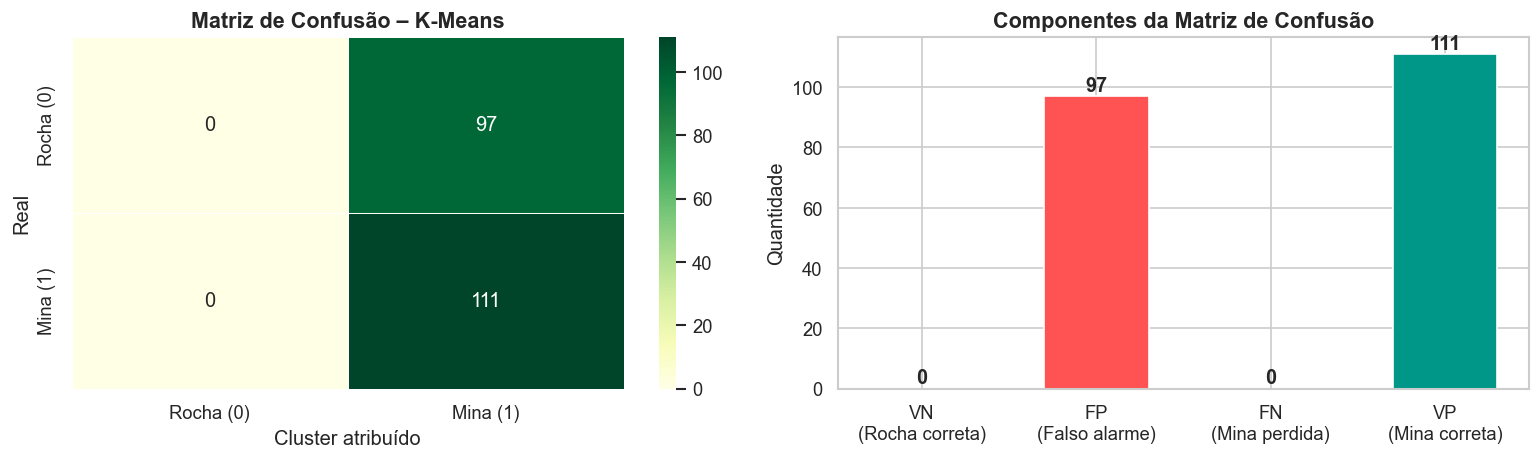


VN=0  FP=97  FN=0  VP=111


In [10]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=['Rocha (0)', 'Mina (1)'],
            yticklabels=['Rocha (0)', 'Mina (1)'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Matriz de Confusão – K-Means', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Cluster atribuído')

# Barras de componentes
labels = ['VN\n(Rocha correta)', 'FP\n(Falso alarme)', 'FN\n(Mina perdida)', 'VP\n(Mina correta)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#4CAF50', '#FF5252', '#FF9800', '#009688']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Componentes da Matriz de Confusão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig('../images/kmeans/kmeans_matriz_confusao.png', bbox_inches='tight')
plt.show()

print(f"\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}")

## 10. Visualização dos Clusters com PCA (2D)

Redução para 2 componentes principais para visualizar a separação dos clusters no espaço bidimensional.

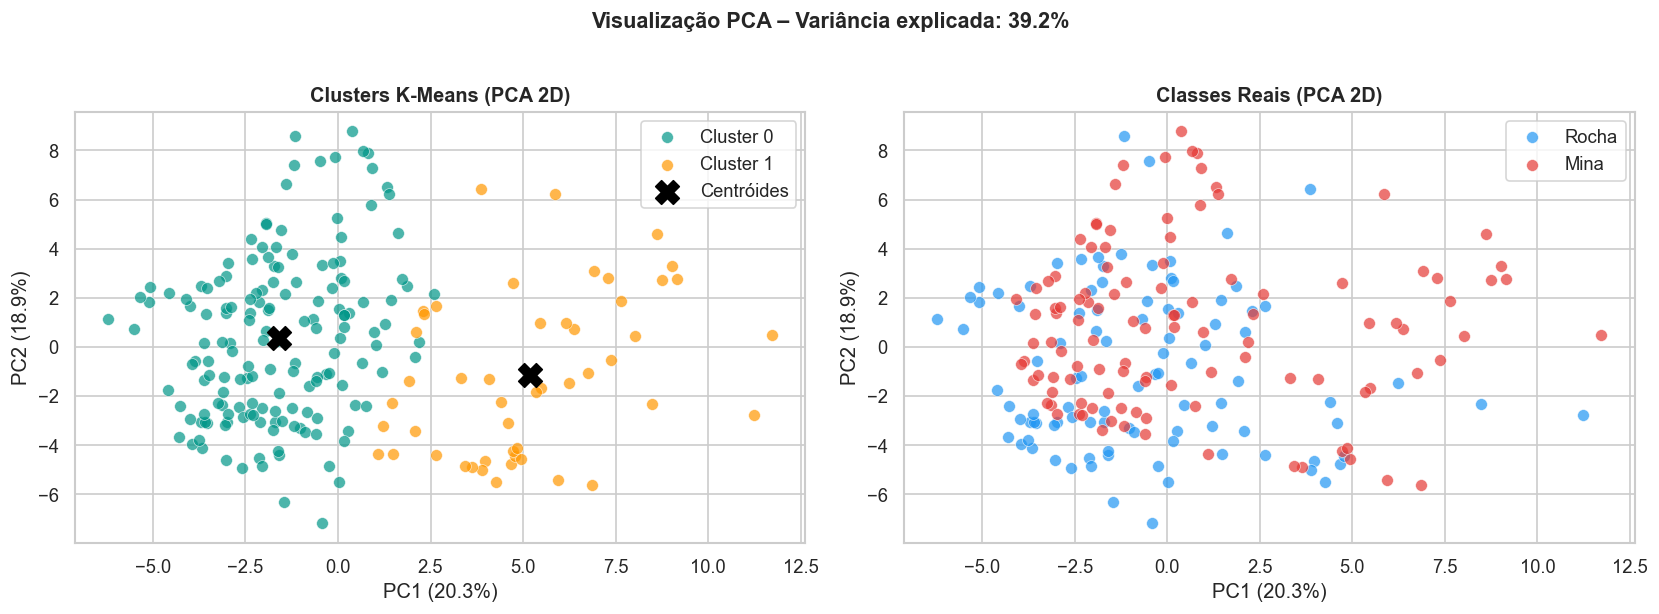

Variância explicada — PC1: 20.35%  PC2: 18.90%  Total: 39.24%


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters preditos pelo K-Means
cores_cluster = ['#009688', '#FF9800']
for cl in [0, 1]:
    mask = clusters == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cores_cluster[cl], label=f'Cluster {cl}',
                    alpha=0.7, edgecolors='white', linewidth=0.4, s=50)

# Centróides no espaço PCA
centroids_pca = pca.transform(modelo.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centróides')
axes[0].set_title('Clusters K-Means (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Rótulos reais para comparação
cores_real = ['#2196F3', '#E53935']
for cl, nome in zip([0, 1], ['Rocha', 'Mina']):
    mask = y_true == cl
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cores_real[cl], label=nome,
                    alpha=0.7, edgecolors='white', linewidth=0.4, s=50)
axes[1].set_title('Classes Reais (PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

var_total = pca.explained_variance_ratio_.sum() * 100
fig.suptitle(f'Visualização PCA – Variância explicada: {var_total:.1f}%',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/kmeans/kmeans_pca.png', bbox_inches='tight')
plt.show()

print(f"Variância explicada — PC1: {pca.explained_variance_ratio_[0]*100:.2f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%  "
      f"Total: {var_total:.2f}%")

## 11. Relatório de Classificação Completo

In [12]:
print(classification_report(y_true, y_pred, target_names=["Rocha (0)", "Mina (1)"]))

              precision    recall  f1-score   support

   Rocha (0)       0.00      0.00      0.00        97
    Mina (1)       0.53      1.00      0.70       111

    accuracy                           0.53       208
   macro avg       0.27      0.50      0.35       208
weighted avg       0.28      0.53      0.37       208



C:\Users\Usuário\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuário\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuário\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics

## 12. Sumário Final

In [13]:
resultados_modelo = pd.DataFrame({
    "Modelo"          : ["K-Means (k=2)"],
    "Acurácia"        : [round(acc, 4)],
    "Precisão"        : [round(precision, 4)],
    "Recall"          : [round(recall, 4)],
    "F1-Score"        : [round(f1, 4)],
    "ARI"                     : [round(ari, 4)],
    "Silhouette Score"        : [round(sil, 4)],
    "Inércia"                 : [round(modelo.inertia_, 4)],
})

dados_processamento = pd.DataFrame({
    "Tempo Treino (s)"         : [round(tempo_treino, 6)],
    "Tempo Inferência (s)"     : [round(tempo_inferencia, 6)],
    "Tempo/Amostra (ms)"       : [round(tempo_por_amostra, 4)],
    "Pico Memória Treino (MB)" : [round(mem_pico_treino_mb, 4)],
    "Delta RAM (MB)"           : [round(ram_depois - ram_antes, 2)],
})

print("=== RESULTADOS DO MODELO ===")
display(resultados_modelo)

print("=== DADOS DE PROCESSAMENTO ===")
display(dados_processamento)

resultados_modelo.to_csv("../results/kmeans/resultados_modelo_kmeans.csv", index=False)
dados_processamento.to_csv("../results/kmeans/dados_processamento_kmeans.csv", index=False)

print("Arquivos CSV gerados com sucesso!")



=== RESULTADOS DO MODELO ===


,Modelo,Acurácia,Precisão,Recall,F1-Score,ARI,Silhouette Score,Inércia
0,K-Means (k=2),0.5337,0.5337,1.0,0.6959,-0.0044,0.2242,10657.0735


=== DADOS DE PROCESSAMENTO ===


,Tempo Treino (s),Tempo Inferência (s),Tempo/Amostra (ms),Pico Memória Treino (MB),Delta RAM (MB)
0,0.030663,0.000487,0.0023,0.0164,0.36


Arquivos CSV gerados com sucesso!
